**STEP 1: Install libraries**

In [1]:
!pip install torch torchvision matplotlib pillow opencv-python

**STEP 2: Mount Google Drive**

In [2]:


from google.colab import drive
drive.mount('/content/drive',force_remount=True)

import os
print("Rain Images :", len(os.listdir('/content/drive/MyDrive/Colab Notebooks/DeLTA_006/Rain100H/train/rainy')))
print("Clean Images :", len(os.listdir('/content/drive/MyDrive/Colab Notebooks/DeLTA_006/Rain100H/train/clean')))

Mounted at /content/drive
Rain Images : 1255
Clean Images : 1255


**STEP 3: Import libraries**

In [3]:
import os
import glob
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

**STEP 4: Set device**

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


**STEP 5: Define dataset path**

In [5]:
dataset_root="/content/drive/MyDrive/Colab Notebooks/DeLTA_006/Rain100H"

train_rainy_dir = os.path.join(dataset_root, "train", "rainy")
train_clean_dir = os.path.join(dataset_root, "train", "clean")
test_rainy_dir  = os.path.join(dataset_root, "test", "rainy")
test_clean_dir  = os.path.join(dataset_root, "test", "clean")

**STEP 6: Create custom dataset class**

In [6]:
class RainDataset(Dataset):
    def __init__(self, rainy_dir, clean_dir, image_size=(256, 256)):
        self.rainy_dir = rainy_dir
        self.clean_dir = clean_dir

        self.rainy_images = sorted(glob.glob(os.path.join(rainy_dir, "*")))
        self.clean_images = sorted(glob.glob(os.path.join(clean_dir, "*")))

        self.transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.rainy_images)

    def __getitem__(self, idx):
        rainy_path = self.rainy_images[idx]
        clean_path = self.clean_images[idx]

        rainy_img = Image.open(rainy_path).convert("RGB")
        clean_img = Image.open(clean_path).convert("RGB")

        rainy_img = self.transform(rainy_img)
        clean_img = self.transform(clean_img)

        return rainy_img, clean_img

**STEP 7: Create train and test dataloaders**

In [7]:
train_dataset = RainDataset(train_rainy_dir, train_clean_dir, image_size=(256, 256))
test_dataset  = RainDataset(test_rainy_dir, test_clean_dir, image_size=(256, 256))

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2)

print("Train images:", len(train_dataset))
print("Test images :", len(test_dataset))

Train images: 1255
Test images : 100


**STEP 8: Show sample rainy-clean pair**

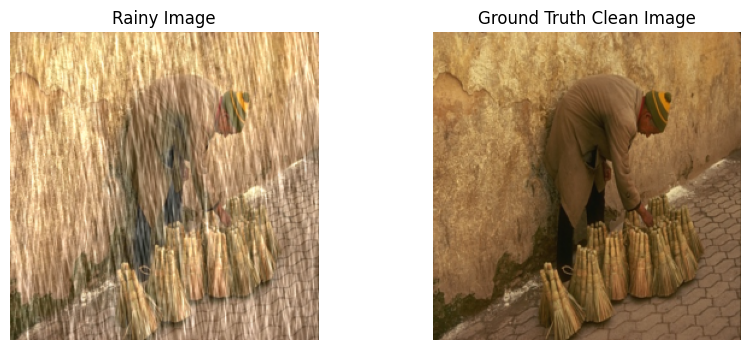

In [8]:
def show_sample(dataset, idx=0):
    rainy, clean = dataset[idx]

    rainy_np = rainy.permute(1, 2, 0).numpy()
    clean_np = clean.permute(1, 2, 0).numpy()

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(rainy_np)
    plt.title("Rainy Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(clean_np)
    plt.title("Ground Truth Clean Image")
    plt.axis("off")

    plt.show()

show_sample(train_dataset, 0)

**STEP 9: Build a ResNet-based deraining model**
*   Input = rainy image
*   model will use residual blocks
*   output = clean image

In [9]:
class ResidualBlock(nn.Module):
    def __init__(self, channels=64):
        super(ResidualBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        )

    def forward(self, x):
        return x + self.block(x)

In [10]:
class ResNetDerain(nn.Module):
    def __init__(self, num_blocks=8):
        super(ResNetDerain, self).__init__()

        self.entry = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

        blocks = []
        for _ in range(num_blocks):
            blocks.append(ResidualBlock(64))
        self.res_blocks = nn.Sequential(*blocks)

        self.exit = nn.Sequential(
            nn.Conv2d(64, 3, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x1 = self.entry(x)
        x2 = self.res_blocks(x1)
        out = self.exit(x2)
        return out

**STEP 10: Initialize model**

In [11]:
model = ResNetDerain(num_blocks=8).to(device)
print(model)

ResNetDerain(
  (entry): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
  )
  (res_blocks): Sequential(
    (0): ResidualBlock(
      (block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
    (1): ResidualBlock(
      (block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
    (2): ResidualBlock(
      (block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
    (3): ResidualBlock(
      (block): Sequential(
        (0): 

**STEP 11: Define loss function and optimizer**

We may use MSEloss also in place of L1Loss but for deraining it is more useful.

In [12]:
criterion = nn.L1Loss()   # good for image restoration
optimizer = optim.Adam(model.parameters(), lr=1e-4)

**STEP 12: Training loop**

In [13]:
num_epochs = 10

train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for rainy_imgs, clean_imgs in train_loader:
        rainy_imgs = rainy_imgs.to(device)
        clean_imgs = clean_imgs.to(device)

        optimizer.zero_grad()

        outputs = model(rainy_imgs)
        loss = criterion(outputs, clean_imgs)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f}")

Epoch [1/10] Loss: 0.1184
Epoch [2/10] Loss: 0.0867
Epoch [3/10] Loss: 0.0778
Epoch [4/10] Loss: 0.0734
Epoch [5/10] Loss: 0.0683
Epoch [6/10] Loss: 0.0661
Epoch [7/10] Loss: 0.0640
Epoch [8/10] Loss: 0.0630
Epoch [9/10] Loss: 0.0614
Epoch [10/10] Loss: 0.0601


**STEP 13: Plot training loss**

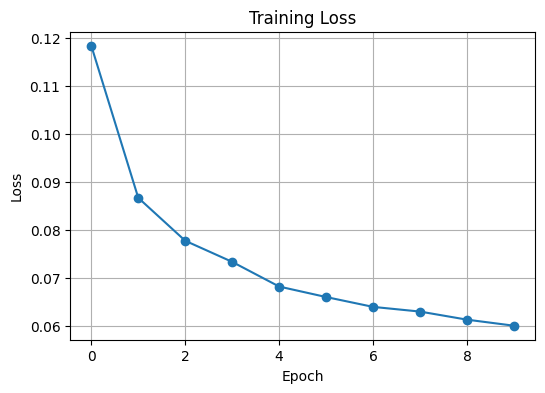

In [14]:
plt.figure(figsize=(6,4))
plt.plot(train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

**STEP 14: Save trained model**

In [15]:
model_path = "/content/drive/MyDrive/Colab Notebooks/DeLTA_006/resnet_derain_rain100h.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)

Model saved at: /content/drive/MyDrive/Colab Notebooks/DeLTA_006/resnet_derain_rain100h.pth


**STEP 15: Load model for demo/inference**

In [16]:
model = ResNetDerain(num_blocks=8).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/Colab Notebooks/DeLTA_006/resnet_derain_rain100h.pth", map_location=device))
model.eval()

ResNetDerain(
  (entry): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
  )
  (res_blocks): Sequential(
    (0): ResidualBlock(
      (block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
    (1): ResidualBlock(
      (block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
    (2): ResidualBlock(
      (block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
    (3): ResidualBlock(
      (block): Sequential(
        (0): 

**STEP 16: Function to test on one rainy image**

In [17]:
def tensor_to_image(tensor):
    img = tensor.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    return img

In [18]:
def predict_and_show(model, rainy_image_path, clean_image_path=None, image_size=(256,256)):
    transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor()
    ])

    rainy_img = Image.open(rainy_image_path).convert("RGB")
    rainy_tensor = transform(rainy_img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(rainy_tensor)

    rainy_np = rainy_tensor.squeeze(0).cpu().permute(1,2,0).numpy()
    output_np = output.squeeze(0).cpu().permute(1,2,0).numpy()
    output_np = np.clip(output_np, 0, 1)

    if clean_image_path is not None:
        clean_img = Image.open(clean_image_path).convert("RGB")
        clean_tensor = transform(clean_img)
        clean_np = clean_tensor.permute(1,2,0).numpy()

        plt.figure(figsize=(15,5))

        plt.subplot(1,3,1)
        plt.imshow(rainy_np)
        plt.title("Rainy Input")
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.imshow(output_np)
        plt.title("Predicted Clear Image")
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.imshow(clean_np)
        plt.title("Ground Truth Clean Image")
        plt.axis("off")

        plt.show()
    else:
        plt.figure(figsize=(10,5))

        plt.subplot(1,2,1)
        plt.imshow(rainy_np)
        plt.title("Rainy Input")
        plt.axis("off")

        plt.subplot(1,2,2)
        plt.imshow(output_np)
        plt.title("Predicted Clear Image")
        plt.axis("off")

        plt.show()

**STEP 17: Run demo on Rain100H rainy image**

/content/drive/MyDrive/Colab Notebooks/DeLTA_006/Rain100H/test/rainy/norain-1.png
/content/drive/MyDrive/Colab Notebooks/DeLTA_006/Rain100H/test/clean/norain-1.png


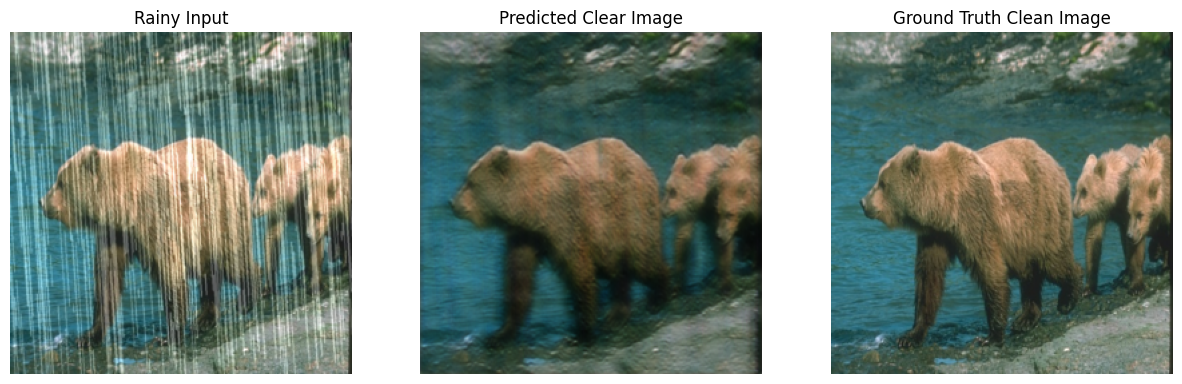

In [28]:
# rainy_files = sorted(os.listdir(test_rainy_dir))
# clean_files = sorted(os.listdir(test_clean_dir))

# # sample_rainy = os.path.join(test_rainy_dir, os.listdir(test_rainy_dir)[1])
# # sample_clean = os.path.join(test_clean_dir, os.listdir(test_clean_dir)[1])
# rainy_files = sorted(os.listdir(test_rainy_dir))
# clean_files = sorted(os.listdir(test_clean_dir))

# sample_rainy = os.path.join(test_rainy_dir, rainy_files[7])
# sample_clean = os.path.join(test_clean_dir, clean_files[7])

# print(sample_rainy)
# print(sample_clean)

# predict_and_show(model, sample_rainy, sample_clean)

# # predict_and_show(model, sample_rainy, sample_clean)

filename = "norain-1.png"   # change to any image you want

sample_rainy = os.path.join(test_rainy_dir, filename)
sample_clean = os.path.join(test_clean_dir, filename)

print(sample_rainy)
print(sample_clean)

predict_and_show(model, sample_rainy, sample_clean)

**What exactly will happen in the demo?**

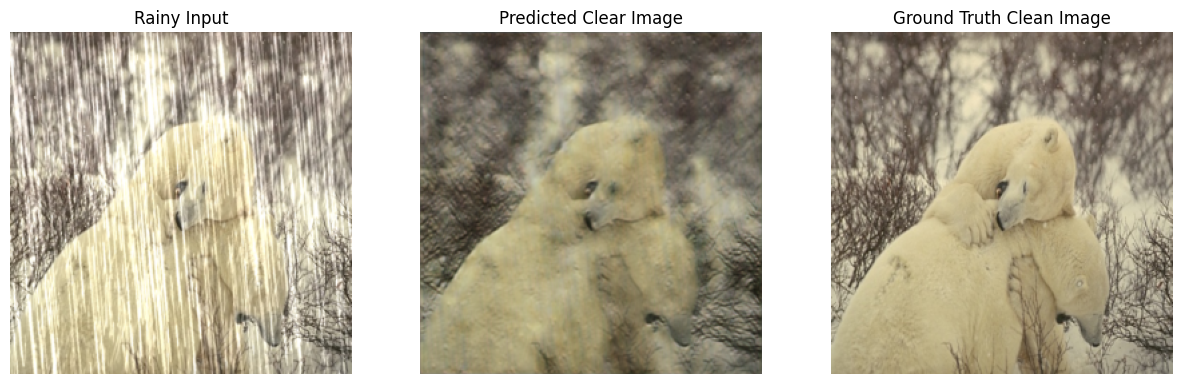

In [20]:
sample_rainy = "/content/drive/MyDrive/Colab Notebooks/DeLTA_006/Rain100H/test/rainy/norain-6.png"
sample_clean = "/content/drive/MyDrive/Colab Notebooks/DeLTA_006/Rain100H/test/clean/norain-6.png"
predict_and_show(model, sample_rainy, sample_clean)